## Plot Results

This notebook is intended to generate plots and videos for the GP-MPC controller when you want to compare multiple log files against each other.

In [1]:
# Libaries
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
from tqdm import tqdm



# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

## Results: MPCC w/o knowledge, MPCC w/ knowledge, GP-MPC w/ linear kernel

Here we want to motivate the need for using a control method which can adapt to chaning model dynamics during runtime.
The MPCC without knowledge faills. The MPCC with knowledge works perfectly. The GP-MPCC gets very close to the latter in terms of performance.

In [6]:
# Load the necessary bags

# Create Logger object (needed to load data)
logger = Logger()

# Set names of the different logs
filename1 = "2024-09-22_17:11:46" # MPCC w/o knowledge
filename2 = "2024-09-22_17:22:22" # MPCC w/ knowledge
filename3 = "2024-09-22_17:48:58" # GP-MPCC with linear kernel
filenames = [filename1, filename2, filename3]

# Load the pandas dataframes
df_list = []
for filename in filenames:
    df_list.append(logger.load_log(filename))

Loading log files from directory: /Users/ahansson/Repos/smallsat-steward/smallsat_sim/../logs/2024-09-22_17:11:46
Loading log files from directory: /Users/ahansson/Repos/smallsat-steward/smallsat_sim/../logs/2024-09-22_17:22:22
Loading log files from directory: /Users/ahansson/Repos/smallsat-steward/smallsat_sim/../logs/2024-09-22_17:48:58


Let's compare the cumulative closed-loop cost of the three configurations.

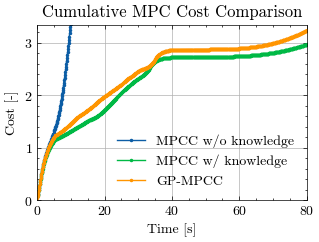

In [17]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 80

# Create a figure for the comparison plot
plt.figure()

# Define labels for each log file
labels = ['MPCC w/o knowledge', 'MPCC w/ knowledge', 'GP-MPCC']

# Iterate through each dataframe and plot the cumulative cost
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in 'mpc_cost' or 'Timestamp'
        df_clean = df[['Timestamp', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-2 * 0.2
        
        # Compute cumulative cost
        df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the cumulative cost with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['cumulative_cost'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Cost [-]')
plt.title('Cumulative MPC Cost Comparison')
plt.legend(loc='best')
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=df_clean['cumulative_cost'].max()+ 0.1)

# Adjust layout to prevent label clipping
plt.tight_layout()